# Frozen transformer surprise prototype

This notebook monitors projected intermediate activations with a tiny online temporal expectation model. It reports error and experience separately; early observations remain `unknown`.

In [3]:
from pathlib import Path
import os
import subprocess
import sys

repo_dir = Path("/content/neural-expectation")
if not (repo_dir / "pyproject.toml").exists():
    subprocess.run(
        ["git", "clone", "https://github.com/sebastiantiesmeyer/neural-expectation.git", str(repo_dir)],
        check=True,
    )
os.chdir(repo_dir)
sys.path.insert(0, str(repo_dir / "src"))
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", ".[notebook]"], check=True)

import matplotlib.pyplot as plt
import numpy as np
import torch
from transformer_surprise.activations import project_selected_layers
from transformer_surprise.config import load_config
from transformer_surprise.model import FrozenTransformer
from transformer_surprise.projection import FixedRandomProjection
from transformer_surprise.state_space import RLSStateSpace

In [4]:
config = load_config("configs/default.yaml")
encoder = FrozenTransformer.from_pretrained(config.model_name, config.layers, config.device, config.dtype)
projection = FixedRandomProjection(encoder.model.config.hidden_size, config.projection_dim, config.projection_seed)
print(f"device: {encoder.device}; layers: {config.layers}")

config.json:   0%|          | 0.00/569 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/396 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors: reconstructing file:   0%|          |  0.00B /  375MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

device: cpu; layers: [2, 6, 10]


In [5]:
sentences = [
    "The cat sat on the mat.",
    "The dog sat by the door.",
    "The cat slept on the chair.",
    "The cat sat on the mat.",
    "The dog sat by the door.",
    "The cta sat on the mat.",
    "The cat transformed into a neutron star.",
]
encoded = encoder.tokenizer(sentences, return_tensors="pt", padding=True, truncation=True)
hidden = encoder.hidden_states(sentences)
projected = project_selected_layers(hidden, projection, encoded["attention_mask"])
print({layer: tuple(values.shape) for layer, values in projected.items()})

{2: (7, 32), 6: (7, 32), 10: (7, 32)}


In [6]:
models = {layer: RLSStateSpace(config.projection_dim, config.sidecar.forgetting_factor, config.sidecar.regularization) for layer in config.layers}
records = []
for index in range(len(sentences) - 1):
    for layer, sidecar in models.items():
        result = sidecar.update(projected[layer][index].numpy(), projected[layer][index + 1].numpy())
        records.append({"step": index, "layer": layer, **result.as_dict()})
        print(f"step={index} layer={layer} status={result.status} error={result.error:.3f} confidence={result.confidence:.2f}")

step=0 layer=2 status=unknown error=14.118 confidence=0.20
step=0 layer=6 status=unknown error=78.658 confidence=0.20
step=0 layer=10 status=unknown error=65.489 confidence=0.20
step=1 layer=2 status=unknown error=1.054 confidence=0.40
step=1 layer=6 status=unknown error=0.547 confidence=0.40
step=1 layer=10 status=unknown error=0.537 confidence=0.40
step=2 layer=2 status=unknown error=0.188 confidence=0.60
step=2 layer=6 status=unknown error=0.225 confidence=0.60
step=2 layer=10 status=unknown error=0.320 confidence=0.60
step=3 layer=2 status=unknown error=0.614 confidence=0.80
step=3 layer=6 status=unknown error=0.239 confidence=0.80
step=3 layer=10 status=unknown error=0.283 confidence=0.80
step=4 layer=2 status=expected error=0.902 confidence=1.00
step=4 layer=6 status=expected error=0.388 confidence=1.00
step=4 layer=10 status=expected error=0.525 confidence=1.00
step=5 layer=2 status=expected error=0.775 confidence=1.00
step=5 layer=6 status=expected error=0.547 confidence=1.00
s

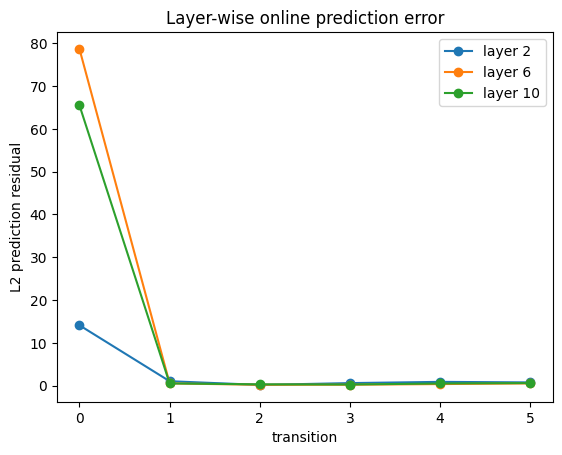

In [7]:
for layer in config.layers:
    points = [record for record in records if record["layer"] == layer]
    plt.plot([point["step"] for point in points], [point["error"] for point in points], marker="o", label=f"layer {layer}")
plt.xlabel("transition")
plt.ylabel("L2 prediction residual")
plt.title("Layer-wise online prediction error")
plt.legend()
plt.yscale("log")
plt.show()